In [2]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength

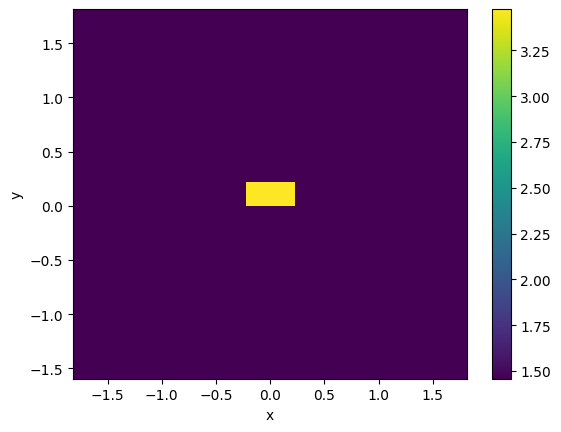

In [4]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=450 * nm, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1.6, # Parameters of the grid 
    grid_resolution=40, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

deep_waveguide.plot_index()

In [5]:
wavelength = np.linspace(1500, 1600,11) * nm

SOI_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=450 * nm, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=wavelength, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1.6, # Parameters of the grid 
    grid_resolution=40, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

res_neff = SOI_waveguide.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te = SOI_waveguide.fraction_te # Wavelength-dependent vector
res_tm = SOI_waveguide.fraction_tm # Wavelength-dependent vector

/home/nixtropy/Topic-6-WDM-Cascaded-MZIs/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/nixtropy/Topic-6-WDM-Cascaded-MZIs/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/nixtropy/Topic-6-WDM-Cascaded-MZIs/.venv/lib/python3.12

18:04:17 CEST WARNING: Mode field at frequency index 0, mode index 3 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 1, mode index 3 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 2, mode index 3 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 3, mode index 3 does not   
              decay at the plane boundaries.                                    

...

              WARNING: Mode field at frequency index 8, mode index 3 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 9, mode index 3 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 10, mode index 3 does not  
              decay at the plane boundaries.                                    

              WARNING: The group index was not computed. To calculate group     
              index, pass 'group_index_step = True' in the 'ModeSpec'.          

2026-05-01 18:04:17.859 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_cd131994f3942447.npz.


In [6]:
np.save("SOI_Waveguide.npy", {
    "wavelength": wavelength,
    "neff": res_neff
})

In [7]:
data = np.load("SOI_Waveguide.npy", allow_pickle=True).item()

wavelength = data["wavelength"]
neff_SOI = data["neff"] # deep_neff[:, 0] = TE_0
lambda0 = 1.55
wavelengthshift = wavelength-lambda0


In [8]:
neff_TE_0 = neff_SOI[:, 0] # TE_0

In [9]:
coeffs = np.polyfit(wavelengthshift, neff_TE_0.real, 2)

n3, n2, n1 = coeffs
lambda0 = 1.55   # micrometers
c = 3e8          # m/s

# neff en lambda0
neff = n1

# primera derivada en lambda0
dneff_dlambda = n2

# group index
ng = neff - lambda0 * dneff_dlambda

# segunda derivada
d2neff_dlambda2 = 2*n3

# dispersion parameter
D = -(lambda0/c) * d2neff_dlambda2

print(f"n3 = {n3:.2f}")
print(f"n2 = {n2:.2f}")
print(f"n1 = {n1:.2f}")
print(f"Effective index neff = {neff:.2f}")
print(f"Group index ng = {ng:.2f}")
print(f"Dispersion parameter D = {D:.2e}")

n3 = -0.04
n2 = -1.22
n1 = 2.38
Effective index neff = 2.38
Group index ng = 4.28
Dispersion parameter D = 4.17e-10


/home/nixtropy/Topic-6-WDM-Cascaded-MZIs/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/nixtropy/Topic-6-WDM-Cascaded-MZIs/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


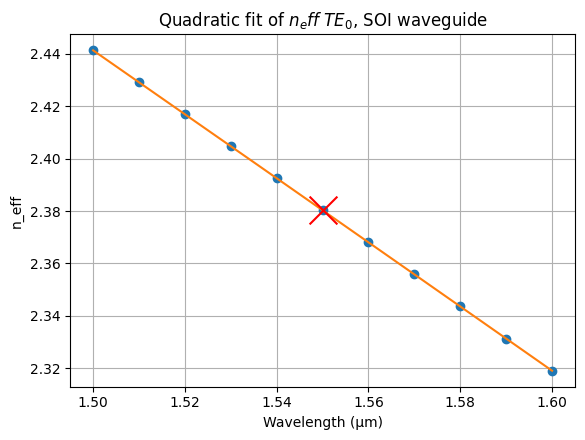

In [ ]:
# Evaluar el polinomio
#-----------------------------
# Deep waveguide TE
#-----------------------------

x_fit = np.linspace(wavelengthshift.min(), wavelengthshift.max(), 200)
y_fit = np.polyval(coeffs, x_fit)

plt.figure(figsize=(7, 4.5))
plt.scatter(lambda0, n1, s=400, marker='x', color='red',zorder=5)
plt.plot(wavelength, neff_TE_0, 'o')
plt.plot(x_fit+lambda0, y_fit)
plt.xlabel("Wavelength (µm)")
plt.ylabel("n_eff")
plt.title("Quadratic fit of $n_eff$ $TE_0$, SOI waveguide")
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.85, 1])
# plt.savefig('LO3_Deep_TE_0.png', bbox_inches='tight')

# SIN Waveguide

In [13]:
wavelength = np.linspace(1500, 1600,11) * nm

SIN_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=1200 * nm, # Waveguide width
    core_thickness=300 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=wavelength, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1.2, # Parameters of the grid 
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

res_neff = SIN_waveguide.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te = SIN_waveguide.fraction_te # Wavelength-dependent vector
res_tm = SIN_waveguide.fraction_tm # Wavelength-dependent vector

/home/nixtropy/Topic-6-WDM-Cascaded-MZIs/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/nixtropy/Topic-6-WDM-Cascaded-MZIs/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/nixtropy/Topic-6-WDM-Cascaded-MZIs/.venv/lib/python3.12

18:14:53 CEST WARNING: Mode field at frequency index 0, mode index 3 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 1, mode index 3 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 2, mode index 3 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 3, mode index 3 does not   
              decay at the plane boundaries.                                    

...

              WARNING: Mode field at frequency index 9, mode index 2 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 9, mode index 3 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 10, mode index 2 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 10, mode index 3 does not  
              decay at the plane boundaries.                                    

2026-05-01 18:14:54.442 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_e70065e5b5dc42c3.npz.


In [14]:
np.save("SIN_Waveguide.npy", {
    "wavelength": wavelength,
    "neff": res_neff
})

In [16]:
data = np.load("SIN_Waveguide.npy", allow_pickle=True).item()

wavelength = data["wavelength"]
neff_SIN = data["neff"] # deep_neff[:, 0] = TE_0
lambda0 = 1.55
wavelengthshift = wavelength-lambda0

In [17]:
neff_TE_0 = neff_SIN[:, 0] # TE_0

In [18]:
coeffs = np.polyfit(wavelengthshift, neff_TE_0.real, 2)

n3, n2, n1 = coeffs
lambda0 = 1.55   # micrometers
c = 3e8          # m/s

# neff en lambda0
neff = n1

# primera derivada en lambda0
dneff_dlambda = n2

# group index
ng = neff - lambda0 * dneff_dlambda

# segunda derivada
d2neff_dlambda2 = 2*n3

# dispersion parameter
D = -(lambda0/c) * d2neff_dlambda2

print(f"n3 = {n3:.2f}")
print(f"n2 = {n2:.2f}")
print(f"n1 = {n1:.2f}")
print(f"Effective index neff = {neff:.2f}")
print(f"Group index ng = {ng:.2f}")
print(f"Dispersion parameter D = {D:.2e}")

n3 = 0.10
n2 = -0.22
n1 = 1.60
Effective index neff = 1.60
Group index ng = 1.94
Dispersion parameter D = -1.01e-09


/home/nixtropy/Topic-6-WDM-Cascaded-MZIs/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/nixtropy/Topic-6-WDM-Cascaded-MZIs/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


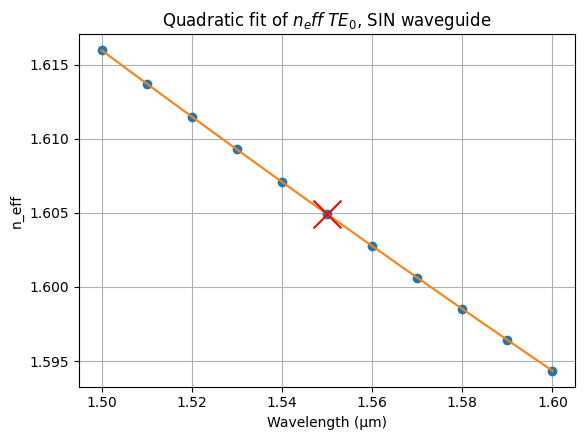

In [19]:
# Evaluar el polinomio
#-----------------------------
# Deep waveguide TE
#-----------------------------

x_fit = np.linspace(wavelengthshift.min(), wavelengthshift.max(), 200)
y_fit = np.polyval(coeffs, x_fit)

plt.figure(figsize=(7, 4.5))
plt.scatter(lambda0, n1, s=400, marker='x', color='red',zorder=5)
plt.plot(wavelength, neff_TE_0, 'o')
plt.plot(x_fit+lambda0, y_fit)
plt.xlabel("Wavelength (µm)")
plt.ylabel("n_eff")
plt.title("Quadratic fit of $n_eff$ $TE_0$, SIN waveguide")
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.85, 1])
# plt.savefig('LO3_Deep_TE_0.png', bbox_inches='tight')